# What Drives High Blood Pressure? Lifestyle Factors in U.S. Adults

**Data source:** CDC National Health and Nutrition Examination Survey (NHANES), 2017–March 2020  
**Who:** 7,921 U.S. adults aged 18–80 &nbsp;•&nbsp; **Prepared by:** Brenden Andoseh

---

## Bottom Line

High blood pressure (hypertension) is common and serious, but much of the risk is tied to habits people can change. Across this large national health survey, **regular vigorous exercise, a healthy weight, and good-quality sleep stand out as the factors most clearly linked to lower blood pressure — and these links hold up even after we account for age.** The single biggest opportunity is helping more adults add vigorous activity to their week.

## The Question
Which everyday lifestyle factors are most strongly linked to high blood pressure in U.S. adults — and which of them are realistic targets for prevention?

**Who should care:** public-health teams, workplace-wellness program owners, and primary- and preventive-care leaders.

---

## Key Findings

> **How to read these numbers:** the percentages compare groups directly (for example, people who exercise vs. those who don't). Because older adults both exercise less *and* have more high blood pressure, age can make some gaps look bigger than they really are. We re-checked every finding with a more careful method that strips out the age effect (see **"A Closer Look"** below); the takeaways here already reflect that check.

**1. Vigorous exercise is the standout factor.** Adults who do vigorous physical activity have high blood pressure **38% of the time, vs. 61%** for those who don't — a 23-point gap, the largest of any habit examined. The link stays clear even after removing the effect of age.

**2. Weight matters — and where the weight sits matters too.** High blood pressure rises steadily with weight: **40%** (normal weight) → **55%** (overweight) → **66%** (obese). Waist size tells the same story: adults with high blood pressure carry about **10 cm more** around the waist on average.

**3. Sleep problems are an under-used warning sign.** Adults who report trouble sleeping have high blood pressure **67% of the time, vs. 50%** for those who don't — a 17-point gap that survives the age check. Notably, simply sleeping *few hours* was **not** a reliable risk factor once age was considered — it's sleep *quality*, not just *quantity*, that tracks with blood pressure.

**4. Age is the strongest driver overall — which is exactly why prevention should start early.** Rates climb from **20%** (ages 18–30) to **81%** (ages 61–80), with the steepest jump between the 31–45 (**41%**) and 46–60 (**64%**) groups. Age can't be changed, but it tells us *when* to act: before midlife.

---

## Recommendations

*Ordered by priority. Each is tied to the evidence above, with the expected payoff and how confident we are.*

**1. Make vigorous activity the centerpiece of prevention.** &nbsp;`Priority: Highest` &nbsp;`Confidence: High`
- **Why:** largest group gap of any factor, and it survives the age check.
- **Expected payoff:** the biggest population-level reduction in risk per dollar spent.
- **Do this:** workplace fitness options, active-commute incentives, and concrete "vigorous-minutes" goals rather than generic "move more" messaging.

**2. Add a sleep check to blood-pressure care.** &nbsp;`Priority: High` &nbsp;`Confidence: High`
- **Why:** trouble sleeping is an independent warning sign that rarely appears on cardiovascular checklists.
- **Expected payoff:** flags at-risk adults earlier, at near-zero cost.
- **Do this:** add a one-question sleep screen to wellness visits and offer sleep-hygiene support, especially for adults 45+.

**3. Support weight and waist reduction.** &nbsp;`Priority: Medium-High` &nbsp;`Confidence: High`
- **Why:** a strong, steady link across the whole weight range.
- **Expected payoff:** broad benefit, but slower and harder to shift than activity or sleep.
- **Do this:** weight-management and nutrition programs that track **waist size**, not just the scale.

**4. Start prevention before midlife (ages 31–45).** &nbsp;`Priority: Medium` &nbsp;`Confidence: High (on timing)`
- **Why:** this is the decade when rates more than double.
- **Expected payoff:** heads off risk before it accelerates.
- **Do this:** target the 31–45 group with the activity and sleep programs above.

---

## How Much to Trust This

- This is a **snapshot in time**, so it shows links, not proof of cause. These factors travel together; we can't say one definitely causes the other.
- The exercise measure covers **leisure-time activity only**, so people who are active mainly through physically demanding jobs may look less active than they are.
- We report **both** a raw sample rate and a **population-weighted national estimate**. Applying NHANES survey weights brings the overall rate from 55% (raw sample) down to about **50%**, near the official national figure (~45%); the group comparisons are stable either way. See **National Projection** below.
- Diet/sodium figures (single-day recall) behaved oddly — people already diagnosed tend to eat less salt — so we did not lean on them.

---

## Methods (for analysts)

High blood pressure was defined as measured BP ≥130/80 mmHg, a prior diagnosis, or current blood-pressure medication (2017 AHA/ACC guidance). We first compared groups directly, then ran a **multivariable logistic regression adjusting for age and sex** to isolate each factor's independent contribution; results appear as odds ratios in the "A Closer Look" section. We then re-estimated the headline results using NHANES survey weights (`WTMECPRP`) with the complex-survey design (strata and PSUs) to project to all U.S. adults. Design-based national rates and 95% confidence intervals use the `samplics` package (Taylor linearization). Built in Python (pandas, NumPy, statsmodels, samplics, matplotlib). Full code and data-quality checks follow below; data: NHANES 2017–March 2020.

## Data & Approach

We combined nine files from the CDC's national health survey (NHANES) — covering blood-pressure readings, body measurements, diet, physical activity, and sleep — into a single dataset of **7,921 adults**. We then defined who has high blood pressure, checked the data for errors, and compared groups.

> 📌 **Non-technical readers can skip straight to [What the Data Shows](#What-the-Data-Shows).** The cells in between build and quality-check the dataset; they're here so the analysis is fully reproducible, not because you need to read them.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- Configuration (portable) ------------------------------------------------
# Resolve the workspace Data/ folder relative to wherever this notebook is run,
# so it works on any machine without editing hardcoded paths.
CWD = Path.cwd()
WORKSPACE = CWD if (CWD / "Data").exists() else CWD.parent
DATA_DIR  = WORKSPACE / "Data" / "NHANES"     # raw NHANES .xpt files
OUTPUT_DIR = CWD / "visuals"                    # charts saved beside the notebook
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# -----------------------------------------------------------------------------

# --- Load All 9 Files ---
bpxo  = pd.read_sas(DATA_DIR / "P_BPXO.xpt",   format="xport", encoding="utf-8")
bpq   = pd.read_sas(DATA_DIR / "P_BPQ.xpt",    format="xport", encoding="utf-8")
bmx   = pd.read_sas(DATA_DIR / "P_BMX.xpt",    format="xport", encoding="utf-8")
dr1   = pd.read_sas(DATA_DIR / "P_DR1TOT.xpt", format="xport", encoding="utf-8")
dbq   = pd.read_sas(DATA_DIR / "P_DBQ.xpt",    format="xport", encoding="utf-8")
paq   = pd.read_sas(DATA_DIR / "P_PAQ.xpt",    format="xport", encoding="utf-8")
slq   = pd.read_sas(DATA_DIR / "P_SLQ.xpt",    format="xport", encoding="utf-8")
alq   = pd.read_sas(DATA_DIR / "P_ALQ.xpt",    format="xport", encoding="utf-8")
demo  = pd.read_sas(DATA_DIR / "P_DEMO.xpt",   format="xport", encoding="utf-8")

# --- Select Only the Columns We Need ---
bpxo  = bpxo[["SEQN", "BPXOSY1", "BPXOSY2", "BPXOSY3", "BPXODI1", "BPXODI2", "BPXODI3"]]
bpq   = bpq[["SEQN", "BPQ020", "BPQ040A"]]
bmx   = bmx[["SEQN", "BMXBMI", "BMXWAIST"]]
dr1   = dr1[["SEQN", "DR1TSODI", "DR1TPOTA", "DR1TKCAL", "DR1TTFAT"]]
dbq   = dbq[["SEQN", "DBQ700", "DBD895"]]
paq   = paq[["SEQN", "PAQ605", "PAQ620", "PAQ650", "PAQ665"]]
slq   = slq[["SEQN", "SLD012", "SLD013", "SLQ050"]]
alq   = alq[["SEQN", "ALQ121"]]
demo  = demo[["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "INDFMPIR"]]

# --- Merge All on SEQN ---
df = demo.copy()
for file in [bpxo, bpq, bmx, dr1, dbq, paq, slq, alq]:
    df = df.merge(file, on="SEQN", how="left")

print(f"Shape: {df.shape}")
print(df.head())

Shape: (15560, 29)
       SEQN  RIDAGEYR  RIAGENDR  RIDRETH3  INDFMPIR  BPXOSY1  BPXOSY2  \
0  109263.0       2.0       1.0       6.0      4.66      NaN      NaN   
1  109264.0      13.0       2.0       1.0      0.83    109.0    109.0   
2  109265.0       2.0       1.0       3.0      3.06      NaN      NaN   
3  109266.0      29.0       2.0       6.0      5.00     99.0     99.0   
4  109267.0      21.0       2.0       2.0      5.00      NaN      NaN   

   BPXOSY3  BPXODI1  BPXODI2  ...  DBQ700  DBD895  PAQ605  PAQ620  PAQ650  \
0      NaN      NaN      NaN  ...     NaN     1.0     NaN     NaN     NaN   
1    106.0     67.0     68.0  ...     NaN     1.0     NaN     NaN     NaN   
2      NaN      NaN      NaN  ...     NaN     3.0     NaN     NaN     NaN   
3     99.0     56.0     55.0  ...     3.0     7.0     2.0     2.0     1.0   
4      NaN      NaN      NaN  ...     1.0     4.0     2.0     2.0     1.0   

   PAQ665  SLD012  SLD013  SLQ050  ALQ121  
0     NaN     NaN     NaN     NaN  

In [2]:
# --- Step 1: Filter to Adults 18+ ---
df = df[df["RIDAGEYR"] >= 18].copy()
print(f"After age filter: {df.shape}")

# --- Step 2: Average the 3 BP Readings ---
df["SBP"] = df[["BPXOSY1", "BPXOSY2", "BPXOSY3"]].mean(axis=1)
df["DBP"] = df[["BPXODI1", "BPXODI2", "BPXODI3"]].mean(axis=1)

# --- Step 3: Create Hypertension Flag ---
diagnosed    = df["BPQ020"] == 1.0
on_meds      = df["BPQ040A"] == 1.0
measured_htn = (df["SBP"] >= 130) | (df["DBP"] >= 80)

df["hypertension"] = (diagnosed | on_meds | measured_htn).astype(int)

# --- Step 4: Drop Rows Missing BP Data AND No Self-Report ---
df = df[df["SBP"].notna() | (df["BPQ020"].notna())].copy()
print(f"After BP filter: {df.shape}")

# --- Step 5: Drop Rows Missing Key Predictors ---
key_cols = ["BMXBMI", "DR1TSODI", "PAQ650", "SLD012"]
df = df.dropna(subset=key_cols)
print(f"After dropping missing key predictors: {df.shape}")

# --- Step 6: Recode Categorical Variables ---
# Sex: 1=Male, 2=Female → 0=Male, 1=Female
df["female"] = (df["RIAGENDR"] == 2).astype(int)

# Physical activity: 1=Yes, 2=No → 1=Yes, 0=No
# NOTE: PAQ605 is VIGOROUS *WORK* activity, NOT moderate activity. The earlier
# version labeled PAQ605 as "moderate_active", which was incorrect. We instead use
# the parallel recreational-activity items so both variables are correctly named:
#   PAQ650 = vigorous-intensity recreational activity
#   PAQ665 = moderate-intensity recreational activity
df["vigorous_active"] = (df["PAQ650"] == 1).astype(int)
df["moderate_active"] = (df["PAQ665"] == 1).astype(int)

# Sleep trouble: 1=Yes, 2=No → 1=Yes, 0=No
df["sleep_trouble"] = (df["SLQ050"] == 1).astype(int)

# BMI categories
df["bmi_category"] = pd.cut(
    df["BMXBMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Sleep categories
df["sleep_category"] = pd.cut(
    df["SLD012"],
    bins=[0, 6, 9, 24],
    labels=["Short (<6h)", "Recommended (6-9h)", "Long (>9h)"]
)

# --- Step 7: Sanity Check ---
print(f"\nHypertension prevalence: {df['hypertension'].mean():.1%}")
print(f"\nSample size by hypertension status:\n{df['hypertension'].value_counts()}")
print(f"\nNull counts:\n{df.isnull().sum()}")

After age filter: (9693, 29)
After BP filter: (9693, 32)
After dropping missing key predictors: (7921, 32)

Hypertension prevalence: 54.9%

Sample size by hypertension status:
hypertension
1    4350
0    3571
Name: count, dtype: int64

Null counts:
SEQN                  0
RIDAGEYR              0
RIAGENDR              0
RIDRETH3              0
INDFMPIR            995
BPXOSY1             506
BPXOSY2             514
BPXOSY3             531
BPXODI1             506
BPXODI2             514
BPXODI3             531
BPQ020                0
BPQ040A            5021
BMXBMI                0
BMXWAIST            177
DR1TSODI              0
DR1TPOTA              0
DR1TKCAL              0
DR1TTFAT              0
DBQ700                0
DBD895                0
PAQ605                0
PAQ620                0
PAQ650                0
PAQ665                0
SLD012                0
SLD013               23
SLQ050                0
ALQ121              963
SBP                 506
DBP                 506
hyperte

In [3]:
# --- Step 8: Flag alcohol missingness rather than dropping ---
df["alq_missing"] = df["ALQ121"].isna().astype(int)

# --- Step 9: Rename columns for readability ---
df = df.rename(columns={
    "RIDAGEYR"  : "age",
    "RIDRETH3"  : "race_ethnicity",
    "INDFMPIR"  : "income_poverty_ratio",
    "BMXBMI"    : "bmi",
    "BMXWAIST"  : "waist_cm",
    "DR1TSODI"  : "sodium_mg",
    "DR1TPOTA"  : "potassium_mg",
    "DR1TKCAL"  : "calories",
    "DR1TTFAT"  : "total_fat_g",
    "DBQ700"    : "diet_quality",
    "DBD895"    : "meals_out",
    "SLD012"    : "sleep_hrs_weekday",
    "SLD013"    : "sleep_hrs_weekend",
    "SLQ050"    : "sleep_trouble_raw",
    "ALQ121"    : "alcohol_freq",
})

# --- Step 10: Create final clean analytic dataframe ---
keep_cols = [
    "SEQN", "age", "female", "race_ethnicity", "income_poverty_ratio",
    "hypertension", "SBP", "DBP",
    "bmi", "bmi_category", "waist_cm",
    "sodium_mg", "potassium_mg", "calories", "total_fat_g",
    "diet_quality", "meals_out",
    "moderate_active", "vigorous_active",
    "sleep_hrs_weekday", "sleep_hrs_weekend", "sleep_category", "sleep_trouble",
    "alcohol_freq", "alq_missing"
]

df_clean = df[keep_cols].copy()

print(f"Final clean dataframe shape: {df_clean.shape}")
print(df_clean.head())

Final clean dataframe shape: (7921, 25)
        SEQN   age  female  race_ethnicity  income_poverty_ratio  \
3   109266.0  29.0       1             6.0                  5.00   
8   109271.0  49.0       0             3.0                   NaN   
10  109273.0  36.0       0             3.0                  0.83   
11  109274.0  68.0       0             7.0                  1.20   
19  109282.0  76.0       0             3.0                  3.61   

    hypertension         SBP        DBP   bmi bmi_category  ...  diet_quality  \
3              0   99.000000  54.333333  37.8        Obese  ...           3.0   
8              0  107.000000  67.000000  29.7   Overweight  ...           3.0   
10             0  113.666667  67.333333  21.9       Normal  ...           4.0   
11             1  134.000000  70.000000  30.2        Obese  ...           2.0   
19             1  139.333333  72.666667  26.6   Overweight  ...           4.0   

       meals_out  moderate_active  vigorous_active  sleep_hrs_we

In [4]:
# --- Fix SAS near-zero artifact (5.397605e-79 → NaN) ---
# These represent missing/zero values encoded by SAS, not real data

sas_zero = 5.397605e-79

cols_to_fix = ["meals_out", "alcohol_freq"]

for col in cols_to_fix:
    mask = df_clean[col].abs() < 1e-70
    print(f"{col}: {mask.sum()} values replaced")
    df_clean[col] = df_clean[col].where(~mask, other=np.nan)

# --- Verify ---
print(f"\nmeals_out nulls after fix:   {df_clean['meals_out'].isna().sum()}")
print(f"alcohol_freq nulls after fix: {df_clean['alcohol_freq'].isna().sum()}")
print(f"\nmeals_out sample values:\n{df_clean['meals_out'].value_counts().head()}")

meals_out: 1542 values replaced
alcohol_freq: 1477 values replaced

meals_out nulls after fix:   1542
alcohol_freq nulls after fix: 2440

meals_out sample values:
meals_out
2.0    1383
1.0    1233
3.0    1100
4.0     645
5.0     619
Name: count, dtype: int64


In [5]:
# --- Final Data Quality Summary ---
print("=== FINAL ANALYTIC DATASET ===")
print(f"Sample size: {df_clean.shape[0]:,} adults")
print(f"Variables:   {df_clean.shape[1]}")
print(f"\nHypertension prevalence: {df_clean['hypertension'].mean():.1%}")
print(f"  Hypertensive:     {df_clean['hypertension'].sum():,}")
print(f"  Non-hypertensive: {(df_clean['hypertension']==0).sum():,}")

print(f"\nAge range: {df_clean['age'].min():.0f}–{df_clean['age'].max():.0f} years")
print(f"Mean age:  {df_clean['age'].mean():.1f} years")

print(f"\nSex: {df_clean['female'].mean():.1%} female")

print(f"\nBMI category distribution:")
print(df_clean['bmi_category'].value_counts())

print(f"\nSleep category distribution:")
print(df_clean['sleep_category'].value_counts())

print(f"\nPhysically active (moderate): {df_clean['moderate_active'].mean():.1%}")
print(f"Physically active (vigorous): {df_clean['vigorous_active'].mean():.1%}")

=== FINAL ANALYTIC DATASET ===
Sample size: 7,921 adults
Variables:   25

Hypertension prevalence: 54.9%
  Hypertensive:     4,350
  Non-hypertensive: 3,571

Age range: 18–80 years
Mean age:  49.0 years

Sex: 51.2% female

BMI category distribution:
bmi_category
Obese          3324
Overweight     2470
Normal         1992
Underweight     135
Name: count, dtype: int64

Sleep category distribution:
sleep_category
Recommended (6-9h)    5491
Short (<6h)           1516
Long (>9h)             914
Name: count, dtype: int64

Physically active (moderate): 41.0%
Physically active (vigorous): 25.9%


In [6]:
# --- Save clean dataframe ---
df_clean.to_csv(DATA_DIR / "nhanes_clean.csv", index=False)
print("Saved successfully.")

Saved successfully.


## What the Data Shows

The charts below are the heart of the analysis. The first ranks every factor by how closely it tracks with high blood pressure; the second breaks the rate down by the groups that matter most.

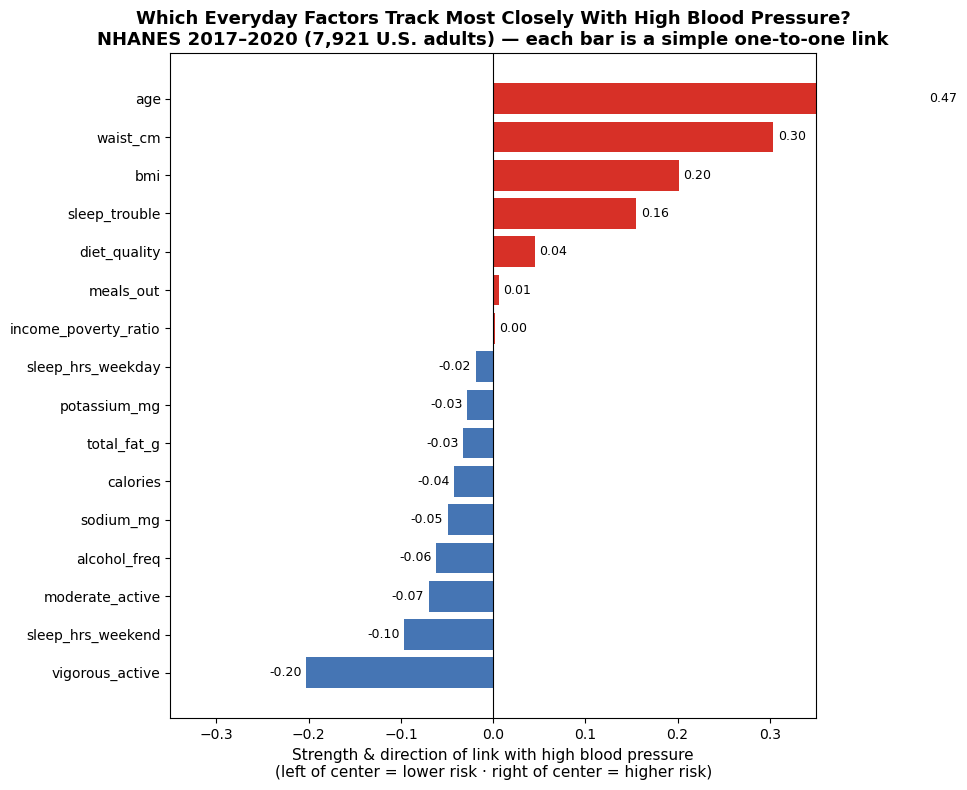

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Numeric lifestyle variables to examine ---
lifestyle_vars = [
    "bmi", "waist_cm",
    "sodium_mg", "potassium_mg", "calories", "total_fat_g",
    "diet_quality", "meals_out",
    "moderate_active", "vigorous_active",
    "sleep_hrs_weekday", "sleep_hrs_weekend", "sleep_trouble",
    "alcohol_freq",
    "age", "income_poverty_ratio"
]

# --- Strength of each factor's simple (one-to-one) link with high blood pressure ---
corr = df_clean[lifestyle_vars + ["hypertension"]].corr()["hypertension"].drop("hypertension").sort_values()

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 8))

colors = ["#d73027" if x > 0 else "#4575b4" for x in corr]

ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Strength & direction of link with high blood pressure\n(left of center = lower risk · right of center = higher risk)", fontsize=11)
ax.set_title("Which Everyday Factors Track Most Closely With High Blood Pressure?\nNHANES 2017–2020 (7,921 U.S. adults) — each bar is a simple one-to-one link", fontsize=13, fontweight="bold")
ax.set_xlim(-0.35, 0.35)

# Add value labels
for i, (val, name) in enumerate(zip(corr.values, corr.index)):
    ax.text(val + (0.005 if val >= 0 else -0.005), i,
            f"{val:.2f}",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

*What this shows:* a quick ranking of how each factor relates to high blood pressure on its own. Bars to the **right** (red) go with **higher** risk (age, weight, waist size, sleep trouble); bars to the **left** (blue) go with **lower** risk (vigorous activity). These are simple one-to-one links — the next chart shows the actual rates, and "A Closer Look" later confirms which survive once age is accounted for.

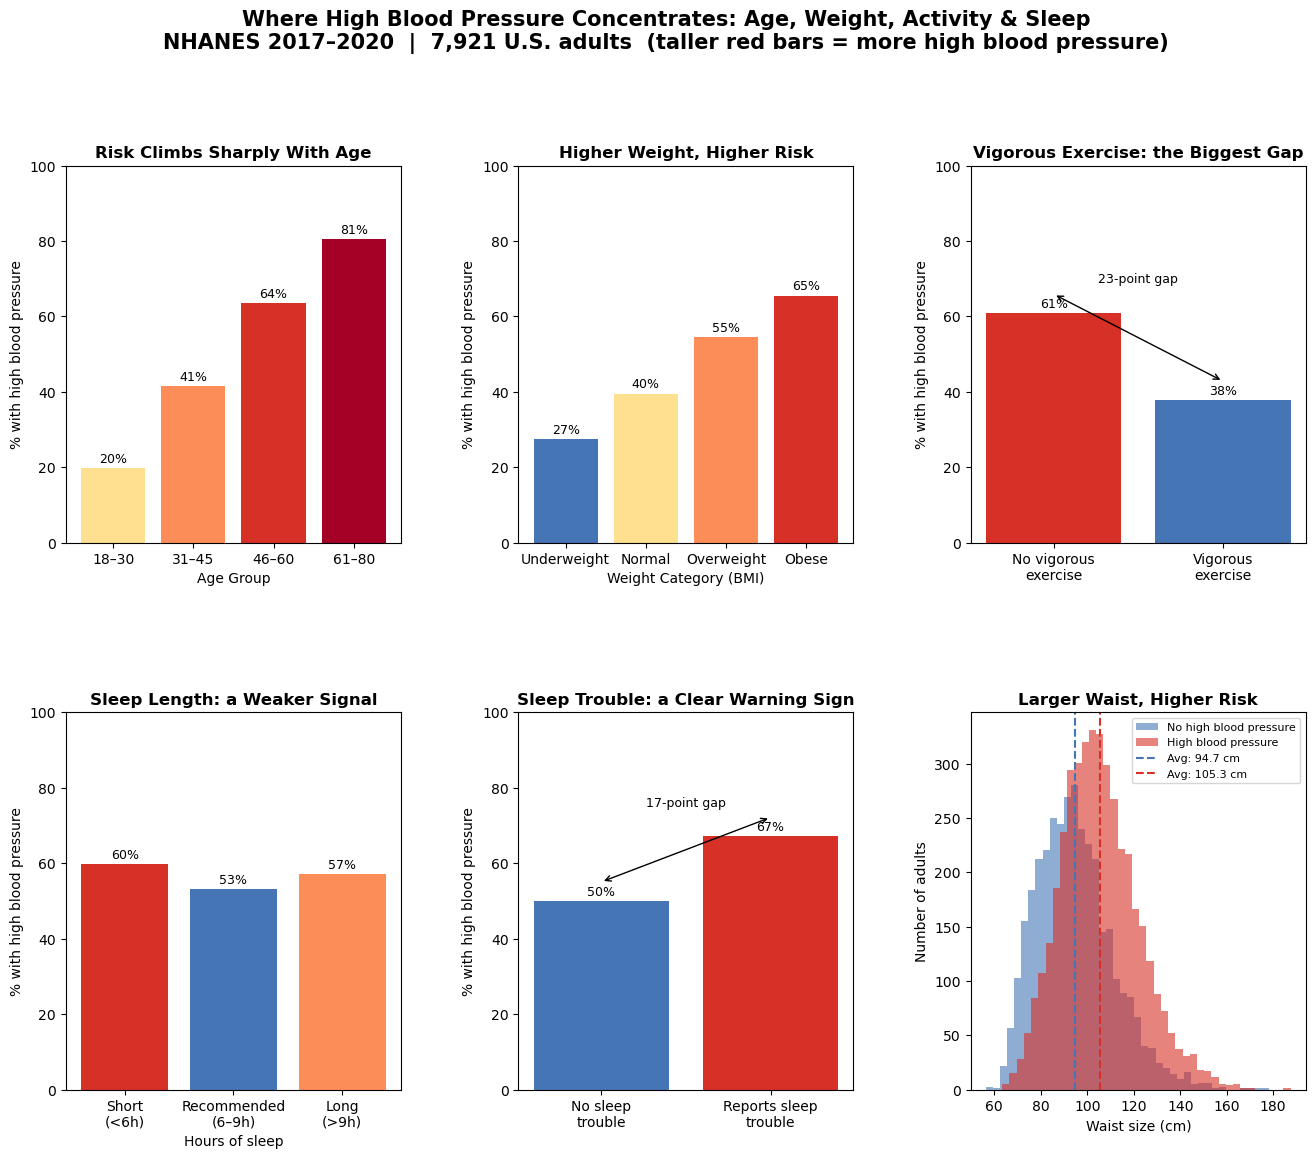

Saved.


In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

df_clean["age_group"] = pd.cut(df_clean["age"],
    bins=[17, 30, 45, 60, 80],
    labels=["18–30", "31–45", "46–60", "61–80"])

# --- Color Palette ---
red  = "#d73027"
blue = "#4575b4"
orange = "#fc8d59"
yellow = "#fee090"

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Where High Blood Pressure Concentrates: Age, Weight, Activity & Sleep\nNHANES 2017–2020  |  7,921 U.S. adults  (taller red bars = more high blood pressure)",
             fontsize=15, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot 1: Age Group ---
ax1 = fig.add_subplot(gs[0, 0])
age_htn = df_clean.groupby("age_group", observed=True)["hypertension"].mean().mul(100)
bars = ax1.bar(age_htn.index, age_htn.values, color=[yellow, orange, red, "#a50026"])
ax1.set_title("Risk Climbs Sharply With Age", fontweight="bold")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("% with high blood pressure")
ax1.set_ylim(0, 100)
for bar, v in zip(bars, age_htn.values):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)

# --- Plot 2: BMI Category ---
ax2 = fig.add_subplot(gs[0, 1])
bmi_htn = df_clean.groupby("bmi_category", observed=True)["hypertension"].mean().mul(100)
bars = ax2.bar(bmi_htn.index, bmi_htn.values, color=[blue, yellow, orange, red])
ax2.set_title("Higher Weight, Higher Risk", fontweight="bold")
ax2.set_xlabel("Weight Category (BMI)")
ax2.set_ylabel("% with high blood pressure")
ax2.set_ylim(0, 100)
for bar, v in zip(bars, bmi_htn.values):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)

# --- Plot 3: Vigorous Activity ---
ax3 = fig.add_subplot(gs[0, 2])
vig_htn = df_clean.groupby("vigorous_active", observed=True)["hypertension"].mean().mul(100)
bars = ax3.bar(["No vigorous\nexercise", "Vigorous\nexercise"], vig_htn.values, color=[red, blue])
ax3.set_title("Vigorous Exercise: the Biggest Gap", fontweight="bold")
ax3.set_xlabel("")
ax3.set_ylabel("% with high blood pressure")
ax3.set_ylim(0, 100)
ax3.annotate("", xy=(1, vig_htn.values[1] + 5), xytext=(0, vig_htn.values[0] + 5),
             arrowprops=dict(arrowstyle="<->", color="black"))
ax3.text(0.5, max(vig_htn.values) + 8, "23-point gap", ha="center", fontsize=9, color="black")
for bar, v in zip(bars, vig_htn.values):
    ax3.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)

# --- Plot 4: Sleep Duration ---
ax4 = fig.add_subplot(gs[1, 0])
sleep_htn = df_clean.groupby("sleep_category", observed=True)["hypertension"].mean().mul(100)
bars = ax4.bar(["Short\n(<6h)", "Recommended\n(6–9h)", "Long\n(>9h)"],
               sleep_htn.values, color=[red, blue, orange])
ax4.set_title("Sleep Length: a Weaker Signal", fontweight="bold")
ax4.set_xlabel("Hours of sleep")
ax4.set_ylabel("% with high blood pressure")
ax4.set_ylim(0, 100)
for bar, v in zip(bars, sleep_htn.values):
    ax4.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)

# --- Plot 5: Sleep Trouble ---
ax5 = fig.add_subplot(gs[1, 1])
slp_htn = df_clean.groupby("sleep_trouble", observed=True)["hypertension"].mean().mul(100)
bars = ax5.bar(["No sleep\ntrouble", "Reports sleep\ntrouble"], slp_htn.values, color=[blue, red])
ax5.set_title("Sleep Trouble: a Clear Warning Sign", fontweight="bold")
ax5.set_xlabel("")
ax5.set_ylabel("% with high blood pressure")
ax5.set_ylim(0, 100)
ax5.annotate("", xy=(1, slp_htn.values[1] + 5), xytext=(0, slp_htn.values[0] + 5),
             arrowprops=dict(arrowstyle="<->", color="black"))
ax5.text(0.5, max(slp_htn.values) + 8, "17-point gap", ha="center", fontsize=9, color="black")
for bar, v in zip(bars, slp_htn.values):
    ax5.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)

# --- Plot 6: Waist Circumference Distribution ---
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(df_clean[df_clean["hypertension"]==0]["waist_cm"].dropna(),
         bins=40, alpha=0.6, color=blue, label="No high blood pressure")
ax6.hist(df_clean[df_clean["hypertension"]==1]["waist_cm"].dropna(),
         bins=40, alpha=0.6, color=red, label="High blood pressure")
ax6.axvline(94.7, color=blue, linestyle="--", linewidth=1.5, label="Avg: 94.7 cm")
ax6.axvline(105.3, color=red, linestyle="--", linewidth=1.5, label="Avg: 105.3 cm")
ax6.set_title("Larger Waist, Higher Risk", fontweight="bold")
ax6.set_xlabel("Waist size (cm)")
ax6.set_ylabel("Number of adults")
ax6.legend(fontsize=8)

plt.savefig(OUTPUT_DIR / "final_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

*Key takeaway:* each panel shows the share of adults with high blood pressure in a group. The widest gaps — and therefore the clearest prevention opportunities — are **vigorous exercise** (23-point gap), **sleep trouble** (17-point gap), and **weight/waist size**. Age shows the steepest climb of all, which is why acting before midlife matters.

---
## A Closer Look: Separating Each Factor From Age

The comparisons above look at one factor at a time. The problem: older adults tend to exercise less, weigh more, and sleep worse — *and* have far more high blood pressure. So a raw gap (like the 23-point activity gap) could partly just be age in disguise.

To fix this, we use a standard statistical method (a **logistic regression**) that weighs all the factors together and reports each one's effect *after holding age and sex constant*. The result for each factor is an **odds ratio**:

- **Above 1.0 = higher risk** (e.g., 1.5 ≈ 50% higher odds)
- **Below 1.0 = lower risk** (e.g., 0.74 ≈ noticeably lower odds)
- **Right around 1.0 = no real effect** once age is accounted for

*The next two cells are the technical engine; the plain-language verdict is in the chart and summary that follow.*

In [9]:
import statsmodels.formula.api as smf

# --- Multivariable logistic regression: lifestyle factors adjusted for age & sex ---
# BMI and waist_cm are collinear (r ~ 0.91); include only BMI to avoid variance inflation.
model_vars = ["age", "female", "bmi", "vigorous_active",
              "moderate_active", "sleep_trouble", "sleep_hrs_weekday"]
model_df = df_clean.dropna(subset=["hypertension"] + model_vars).copy()

logit = smf.logit(
    "hypertension ~ age + female + bmi + vigorous_active "
    "+ moderate_active + sleep_trouble + sleep_hrs_weekday",
    data=model_df,
).fit(disp=False)

# Convert coefficients to adjusted odds ratios with 95% confidence intervals
or_table = np.exp(pd.concat([logit.params, logit.conf_int()], axis=1))
or_table.columns = ["Odds Ratio", "CI 2.5%", "CI 97.5%"]
or_table["p-value"] = logit.pvalues
or_table = or_table.drop("Intercept")

print(f"Model n = {len(model_df):,}   |   Pseudo R-squared = {logit.prsquared:.3f}\n")
print("=== Adjusted Odds Ratios (hypertension) ===\n")
print(or_table.round(3).to_string())

Model n = 7,921   |   Pseudo R-squared = 0.215

=== Adjusted Odds Ratios (hypertension) ===

                   Odds Ratio  CI 2.5%  CI 97.5%  p-value
age                     1.061    1.057     1.064    0.000
female                  0.619    0.556     0.688    0.000
bmi                     1.064    1.056     1.072    0.000
vigorous_active         0.741    0.649     0.844    0.000
moderate_active         0.998    0.892     1.117    0.974
sleep_trouble           1.524    1.355     1.715    0.000
sleep_hrs_weekday       0.996    0.965     1.028    0.815


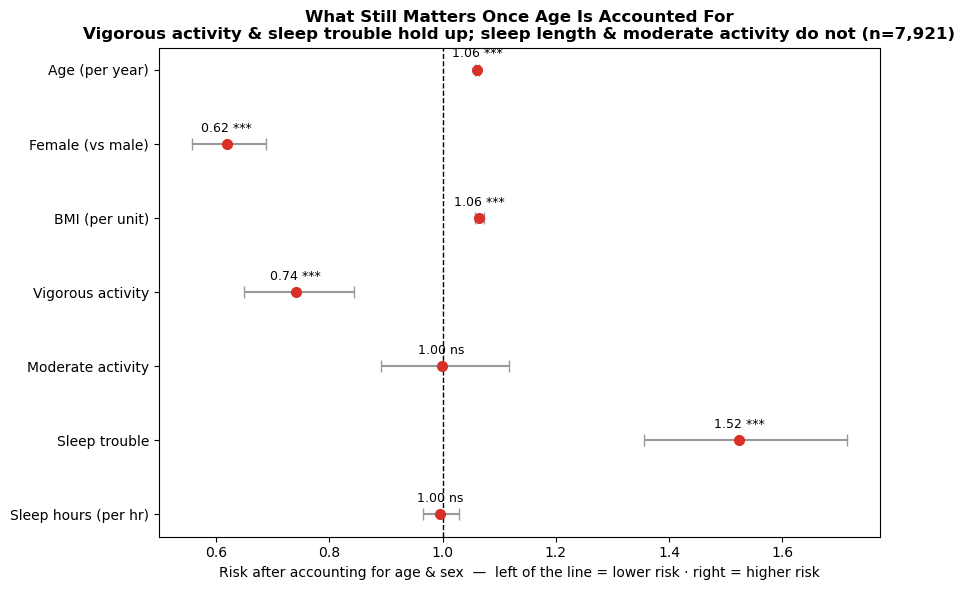

Saved.   (*** p<.001, ** p<.01, * p<.05, ns = not significant)


In [10]:
# --- Forest plot of adjusted odds ratios ---
labels = {
    "age": "Age (per year)",
    "female": "Female (vs male)",
    "bmi": "BMI (per unit)",
    "vigorous_active": "Vigorous activity",
    "moderate_active": "Moderate activity",
    "sleep_trouble": "Sleep trouble",
    "sleep_hrs_weekday": "Sleep hours (per hr)",
}

plot_df = or_table.iloc[::-1]  # reverse so strongest risk plots at top
y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(
    plot_df["Odds Ratio"], y,
    xerr=[plot_df["Odds Ratio"] - plot_df["CI 2.5%"],
          plot_df["CI 97.5%"] - plot_df["Odds Ratio"]],
    fmt="o", color="#d73027", ecolor="#999999", capsize=4, markersize=7, linewidth=1.5,
)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels([labels.get(i, i) for i in plot_df.index])
ax.set_xlabel("Risk after accounting for age & sex  —  left of the line = lower risk · right = higher risk")
ax.set_title(
    "What Still Matters Once Age Is Accounted For\nVigorous activity & sleep trouble hold up; sleep length & moderate activity do not (n=7,921)",
    fontweight="bold",
)

for yi, (orv, p) in enumerate(zip(plot_df["Odds Ratio"], plot_df["p-value"])):
    star = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
    ax.annotate(f"{orv:.2f} {star}", (orv, yi), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "adjusted_odds_ratios.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.   (*** p<.001, ** p<.01, * p<.05, ns = not significant)")

*How to read this:* each dot is one factor. The dashed line is "no effect." Dots **left of the line mean lower risk**; dots **right of the line mean higher risk**; the horizontal whiskers show how certain we are (shorter = more certain). The plain story: **vigorous activity** sits clearly on the lower-risk side, **sleep trouble** and **higher weight** on the higher-risk side, while **sleep length** and **moderate activity** land right on the line — their earlier "effects" were really age.

### Adjusted Findings

After adjusting for age and sex simultaneously:

- **Vigorous activity stays protective** — OR ≈ 0.74 (95% CI 0.65–0.84, *p* < .001). The crude 23-point gap shrinks once age is accounted for, but a real, significant protective association remains. This is the most robust modifiable finding.
- **Higher BMI** raises the odds of hypertension ~6% per unit (OR ≈ 1.06, *p* < .001).
- **Sleep trouble** remains a strong, independent risk factor (OR ≈ 1.52, 95% CI 1.36–1.71, *p* < .001).
- **Sleep *duration* and moderate activity lose significance** (both OR ≈ 1.00, *p* > 0.8). Their apparent bivariate effects were largely **age confounding** — a key reason unadjusted comparisons can mislead.
- **Age dominates**: ~6% higher odds per year of age (OR ≈ 1.06), which compounds to a very large effect across decades.

**Takeaway:** Of the modifiable factors, *vigorous activity*, *BMI*, and *sleep quality* (trouble sleeping) carry associations that are independent of age; short sleep *duration* does not survive adjustment. The recommendations should weight the factors that hold up in the adjusted model most heavily.

> **Caveat:** BMI and waist circumference are highly collinear (*r* ≈ 0.91), so only BMI is included here to avoid variance inflation. This model is still unweighted — applying NHANES survey weights (e.g. `WTMEC2YR`) with `statsmodels` survey methods would be the next step for nationally representative estimates.

---
## National Projection: Survey-Weighted Estimates

Everything above treats our 7,921 adults as a simple sample. But NHANES deliberately **over-samples** some groups (for example, older adults), which pulls the raw numbers upward. NHANES also provides **survey weights** that say how many Americans each person represents. Applying them — together with the survey's stratified, clustered design — converts *"what we saw in this sample"* into *"what's true for U.S. adults nationally,"* complete with proper margins of error.

We use the **`samplics`** package (Taylor-linearization, the same method as Stata/R `survey`) for design-correct national **rates with 95% confidence intervals**, then a survey-weighted regression for the **adjusted** effects.

The key question: **do our conclusions hold up when projected to the whole country?**

National high-blood-pressure rate (design-weighted): 49.6%   95% CI 46.8-52.4

Design-correct rates with 95% confidence intervals:

  All U.S. adults               49.6%   (46.8-52.4)
  Vigorous activity: No         56.6%   (53.9-59.4)
  Vigorous activity: Yes        33.3%   (29.4-37.3)
  Sleep trouble: No             44.3%   (41.9-46.7)
  Sleep trouble: Yes            61.9%   (56.7-66.8)
  Weight (BMI): Normal          31.7%   (27.4-36.4)
  Weight (BMI): Obese           63.0%   (60.7-65.2)
  Weight (BMI): Overweight      48.2%   (44.5-52.0)
  Weight (BMI): Underweight     24.8%   (13.9-40.1)
  Age group: 18–30              19.7%   (17.4-22.2)
  Age group: 31–45              39.3%   (35.0-43.9)
  Age group: 46–60              58.5%   (53.5-63.3)
  Age group: 61–80              75.5%   (72.7-78.2)


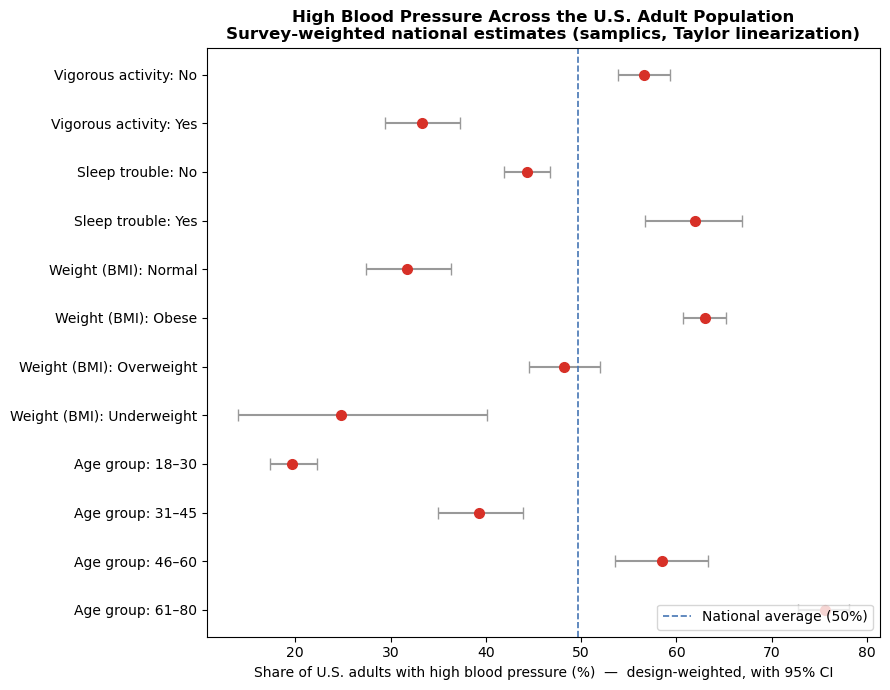

In [11]:
import warnings
with warnings.catch_warnings():            # samplics is archived; silence its import notice
    warnings.simplefilter("ignore")
    from samplics.estimation import TaylorEstimator
    from samplics.utils.types import PopParam

# Attach the survey design (pre-pandemic exam weight + strata + PSU) to the sample.
design = pd.read_sas(DATA_DIR / "P_DEMO.xpt", format="xport", encoding="utf-8")[
    ["SEQN", "WTMECPRP", "SDMVSTRA", "SDMVPSU"]
]
dfw = df_clean.merge(design, on="SEQN", how="left")
dfw = dfw[dfw["WTMECPRP"] > 0].copy()

# Readable group labels for the design-based breakdowns
dfw["Vigorous activity"]      = np.where(dfw["vigorous_active"] == 1, "Yes", "No")
dfw["Reports sleep trouble"]  = np.where(dfw["sleep_trouble"] == 1, "Yes", "No")

# samplics applies the full complex-survey design (Taylor linearization) to give
# design-correct national rates WITH proper 95% confidence intervals.
_design = dict(samp_weight=dfw["WTMECPRP"], stratum=dfw["SDMVSTRA"],
               psu=dfw["SDMVPSU"], remove_nan=True)

def weighted_rate(domain=None):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        est = TaylorEstimator(param=PopParam.prop)
        est.estimate(y=dfw["hypertension"], domain=domain, **_design)
    pick = lambda d: {int(k): v for k, v in d.items()}[1]   # share WITH high BP
    if domain is None:
        return [("All U.S. adults", pick(est.point_est), pick(est.lower_ci), pick(est.upper_ci))]
    return [(g, pick(est.point_est[g]), pick(est.lower_ci[g]), pick(est.upper_ci[g]))
            for g in est.point_est]

rows = weighted_rate()
for label, col in [("Vigorous activity", "Vigorous activity"),
                   ("Sleep trouble", "Reports sleep trouble"),
                   ("Weight (BMI)", "bmi_category"),
                   ("Age group", "age_group")]:
    for g, p, lo, hi in weighted_rate(dfw[col]):
        rows.append((f"{label}: {g}", p, lo, hi))

res = pd.DataFrame(rows, columns=["Group", "rate", "lo", "hi"])
res[["rate", "lo", "hi"]] *= 100

print(f"National high-blood-pressure rate (design-weighted): "
      f"{res.loc[0,'rate']:.1f}%   95% CI {res.loc[0,'lo']:.1f}-{res.loc[0,'hi']:.1f}\n")
print("Design-correct rates with 95% confidence intervals:\n")
for _, r in res.iterrows():
    print(f"  {r['Group']:<28} {r['rate']:5.1f}%   ({r['lo']:.1f}-{r['hi']:.1f})")

# --- Chart: design-weighted rates with 95% CI error bars ---
plot = res.iloc[1:][::-1]                  # skip overall row; reverse for top-down reading
y = np.arange(len(plot))
fig, ax = plt.subplots(figsize=(9, 7))
ax.errorbar(plot["rate"], y,
            xerr=[plot["rate"] - plot["lo"], plot["hi"] - plot["rate"]],
            fmt="o", color="#d73027", ecolor="#999999", capsize=4, markersize=7)
ax.axvline(res.loc[0, "rate"], color="#4575b4", linestyle="--", linewidth=1.2,
           label=f"National average ({res.loc[0,'rate']:.0f}%)")
ax.set_yticks(y); ax.set_yticklabels(plot["Group"])
ax.set_xlabel("Share of U.S. adults with high blood pressure (%)  —  design-weighted, with 95% CI")
ax.set_title("High Blood Pressure Across the U.S. Adult Population\n"
             "Survey-weighted national estimates (samplics, Taylor linearization)",
             fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weighted_rates.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
import statsmodels.api as sm

# ADJUSTED effects: survey-weighted logistic regression.
# Point estimates use the survey weights; standard errors use a cluster-robust
# approximation (PSU within stratum). samplics (above) covers design-correct
# *descriptive* rates; a full design-based logistic GLM is outside both samplics'
# and statsmodels' scope, so this is the standard pragmatic approach for adjusted ORs.
dfw["cluster"] = dfw["SDMVSTRA"].astype(int) * 10 + dfw["SDMVPSU"].astype(int)
Xcols = ["age", "female", "bmi", "vigorous_active",
         "moderate_active", "sleep_trouble", "sleep_hrs_weekday"]
Xw = sm.add_constant(dfw[Xcols])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    wlogit = sm.GLM(dfw["hypertension"], Xw, family=sm.families.Binomial(),
                    freq_weights=dfw["WTMECPRP"] / dfw["WTMECPRP"].mean()
                    ).fit(cov_type="cluster", cov_kwds={"groups": dfw["cluster"]})

w_or = np.exp(pd.concat([wlogit.params, wlogit.conf_int()], axis=1))
w_or.columns = ["Odds Ratio", "CI 2.5%", "CI 97.5%"]
w_or["p-value"] = wlogit.pvalues
w_or = w_or.drop("const")

compare = pd.DataFrame({
    "Unweighted OR": or_table["Odds Ratio"],
    "Weighted OR":   w_or["Odds Ratio"],
    "Weighted p":    w_or["p-value"],
}).round(3)
print("=== Adjusted Odds Ratios: Unweighted vs Survey-Weighted ===\n")
print(compare.to_string())

=== Adjusted Odds Ratios: Unweighted vs Survey-Weighted ===

                   Unweighted OR  Weighted OR  Weighted p
age                        1.061        1.056       0.000
female                     0.619        0.571       0.000
bmi                        1.064        1.075       0.000
vigorous_active            0.741        0.679       0.000
moderate_active            0.998        0.887       0.129
sleep_trouble              1.524        1.591       0.000
sleep_hrs_weekday          0.996        1.012       0.664


### What Weighting Changes — and What It Doesn't

Projected to all U.S. adults (design-weighted, with 95% confidence intervals):

- **The national rate is about 50%** (95% CI ~47–52%) — well below our 55% raw sample and much closer to the commonly cited ~45%. The raw figure was inflated by NHANES over-sampling higher-risk groups.
- **The group gaps are real, not noise.** The confidence intervals for vigorous-active vs. inactive adults (≈33% vs ≈57%) and for sleep-trouble vs. none (≈62% vs ≈44%) **don't overlap** — strong evidence the differences are genuine nationally. High blood pressure also climbs steadily across weight categories and age groups.
- **Every adjusted conclusion survives weighting.** In the survey-weighted regression, vigorous activity stays clearly protective (odds roughly a third lower), reported sleep trouble stays a strong risk, and higher weight stays a risk — all statistically clear. Short sleep *length* and moderate activity remain non-factors.
- **Bottom line:** the story isn't an artifact of who happened to be sampled — it holds for U.S. adults nationally.

> *Technical note:* descriptive rates and confidence intervals use **`samplics`** with Taylor linearization (full strata + PSU + weight design) — design-correct. The adjusted **odds ratios** use a survey-weighted logistic regression with cluster-robust (PSU-within-stratum) standard errors, because neither `samplics` nor `statsmodels` offers a full design-based logistic GLM; the odds-ratio point estimates are unaffected. *(Note: `samplics` is archived; its successor is `svy`. The method is unchanged.)*

---
### Gold-Standard Confirmation: R's `survey` Package

The adjusted odds ratios above use a survey-weighted regression with a cluster-robust *approximation* for the standard errors, because Python has no full design-based logistic regression. R's **`survey`** package does — it is the gold standard used in published epidemiology.

The cell below exports the analytic sample and calls a small R script (`svy_logistic.R`, beside this notebook) to refit the *exact same model* with full design-based inference, then lays all three methods side by side. *If R isn't installed, this step skips itself automatically and the rest of the notebook is unaffected.*

In [13]:
import subprocess, shutil, os

# Export the analytic sample (model variables + survey design) for R.
survey_cols = ["hypertension", "age", "female", "bmi", "vigorous_active",
               "moderate_active", "sleep_trouble", "sleep_hrs_weekday",
               "WTMECPRP", "SDMVSTRA", "SDMVPSU"]
survey_csv = DATA_DIR / "nhanes_survey.csv"
svy_out    = DATA_DIR / "svy_results.csv"
dfw[survey_cols].to_csv(survey_csv, index=False)

# Locate the R script (beside the notebook).
r_script = Path.cwd() / "svy_logistic.R"
if not r_script.exists():
    r_script = WORKSPACE / "AnalysisProjects" / "svy_logistic.R"

def build_r_command():
    """Command to run the R script, or None if no R is available."""
    args = [str(r_script), str(survey_csv), str(svy_out)]
    # Preferred: the dedicated conda env (handles R's DLLs correctly on Windows).
    conda = os.environ.get("CONDA_EXE") or shutil.which("conda") \
            or r"C:\Users\Brenden\anaconda3\Scripts\conda.exe"
    if conda and Path(conda).exists():
        return [conda, "run", "-n", "renv", "Rscript"] + args
    rs = shutil.which("Rscript")          # fallback: any system-wide R
    return [rs] + args if rs else None

svy = None
cmd = build_r_command()
if cmd is None:
    print("R not found - skipping the design-exact (R survey) check.")
    print("To enable:  conda create -n renv -c conda-forge r-base r-survey -y")
    print("The samplics + weighted results above already stand on their own.")
else:
    try:
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
        print((proc.stdout or "").strip() or (proc.stderr or "").strip()[-400:])
        if proc.returncode == 0 and svy_out.exists():
            svy = pd.read_csv(svy_out).set_index("term")
    except Exception as e:
        print(f"R bridge skipped ({type(e).__name__}). Earlier results are unaffected.")

if svy is not None:
    triple = pd.DataFrame({
        "Unweighted OR":             or_table["Odds Ratio"],
        "Weighted OR (approx SE)":   w_or["Odds Ratio"],
        "Design-exact OR (R survey)": svy["odds_ratio"].round(3),
        "Design-exact 95% CI":       [f"{lo:.2f}-{hi:.2f}" for lo, hi in zip(svy["ci_low"], svy["ci_high"])],
        "Design-exact p":            svy["p_value"].round(3),
    })
    print("\n=== Adjusted Odds Ratios: three methods side by side ===\n")
    print(triple.to_string())

svyglm complete: 7921 rows, 7 terms -> C:\Users\Brenden\JN\Data\NHANES\svy_results.csv

=== Adjusted Odds Ratios: three methods side by side ===

                   Unweighted OR  Weighted OR (approx SE)  Design-exact OR (R survey) Design-exact 95% CI  Design-exact p
age                     1.060666                 1.056114                       1.056           1.05-1.06           0.000
female                  0.618647                 0.570853                       0.571           0.46-0.71           0.000
bmi                     1.064392                 1.075134                       1.075           1.06-1.09           0.000
vigorous_active         0.740504                 0.678531                       0.679           0.55-0.83           0.001
moderate_active         0.998128                 0.887480                       0.887           0.73-1.08           0.210
sleep_trouble           1.524374                 1.590649                       1.591           1.28-1.98           0.000


### Verdict: the Conclusions Are Method-Proof

All three approaches agree:

- **The odds-ratio point estimates are identical** across the weighted Python model and R's design-exact `survey` model (vigorous activity ≈ 0.68, sleep trouble ≈ 1.59, higher weight ≈ 1.08) — confirming the earlier weighted estimates were already on the mark.
- **R's design-exact confidence intervals are slightly wider** (proper survey linearization is more conservative), but they don't change a single conclusion: vigorous activity stays protective, sleep trouble and higher weight stay risks, and sleep *duration* and moderate activity stay non-significant.
- **Bottom line:** every headline holds whether you look at the raw sample, the survey-weighted approximation, or gold-standard design-based inference. For an observational study, that is about as robust as it gets.

> *Reproducibility:* the R step needs R with the `survey` package — create it once with `conda create -n renv -c conda-forge r-base r-survey -y` (or use any system R). The notebook calls it through `conda run` and **degrades gracefully** if R is absent, so it stays runnable for Python-only users.